In [3]:
%matplotlib inline

import matplotlib.pylab as plt
import pandas as pd

from tsfresh import extract_features, extract_relevant_features, select_features
from tsfresh.utilities.dataframe_functions import impute
from tsfresh.feature_extraction import ComprehensiveFCParameters

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [4]:
# Load your data
df = pd.read_excel(r"C:\Users\Teresa\Desktop\MBBAS (2ºano)\Tese\Audio_samples\features.xlsx", engine="openpyxl")
df.head(10)

,Unnamed: 0,value__variance_larger_than_standard_deviation,value__has_duplicate_max,value__has_duplicate_min,value__has_duplicate,value__sum_values,value__abs_energy,value__mean_abs_change,value__mean_change,value__mean_second_derivative_central,...,value__fourier_entropy__bins_5,value__fourier_entropy__bins_10,value__fourier_entropy__bins_100,value__permutation_entropy__dimension_3__tau_1,value__permutation_entropy__dimension_4__tau_1,value__permutation_entropy__dimension_5__tau_1,value__permutation_entropy__dimension_6__tau_1,value__permutation_entropy__dimension_7__tau_1,value__query_similarity_count__query_None__threshold_0.0,value__mean_n_absolute_max__number_of_maxima_7
0,GC-F10-10ml_post,1.0,0.0,0.0,0.0,-52281.675511,3.120216e+06,4.701183,-0.048320,0.004339,...,0.090729,0.136002,1.475321,1.774306,3.120190,4.633553,6.031261,6.717061,NaN,86.403545
1,GC-F10-20ml_post,1.0,0.0,0.0,0.0,-46655.779863,2.471471e+06,5.317827,-0.018837,-0.001724,...,0.045395,0.125256,1.237739,1.790893,3.172271,4.741268,6.163044,6.770612,NaN,76.720412
2,GC-F10-20ml_pre,1.0,0.0,0.0,0.0,-53573.255787,3.356791e+06,4.450515,-0.042563,-0.004871,...,0.090729,0.170467,1.009888,1.786668,3.153435,4.694652,6.116663,6.743771,NaN,95.123688
3,GC-F10-3ml_post,1.0,0.0,0.0,0.0,-46062.310836,2.473042e+06,2.213485,-0.036470,0.000172,...,0.045395,0.045395,0.672931,1.758501,3.080309,4.564563,5.907121,6.590524,NaN,70.399839
4,GC-F10-3ml_pre,1.0,0.0,0.0,0.0,-53327.473884,3.007662e+06,3.418790,-0.015807,-0.001639,...,0.045395,0.090729,1.457837,1.788291,3.165334,4.718797,6.152327,6.760165,NaN,70.965554
5,GC-F10-50ml_post,1.0,0.0,0.0,0.0,-36342.681091,1.535744e+06,3.133249,-0.026748,-0.000201,...,0.090729,0.170467,1.537478,1.790738,3.173286,4.736967,6.170202,6.770200,NaN,53.740048
6,GC-F10-50ml_pre,1.0,0.0,0.0,0.0,-52610.438073,2.964569e+06,3.566467,-0.032595,0.001935,...,0.090729,0.200814,1.490408,1.791568,3.164294,4.717500,6.139963,6.760849,NaN,72.715192
7,GC-F10-5ml_post,1.0,0.0,0.0,0.0,-38859.239424,1.855157e+06,1.968737,-0.018158,0.000071,...,0.045395,0.090729,0.698444,1.779252,3.130035,4.667080,6.104532,6.727805,NaN,57.734213
8,GC-F10-5ml_pre,1.0,0.0,0.0,0.0,-48225.512307,2.528879e+06,3.497430,-0.019691,-0.001579,...,0.045395,0.155665,1.537598,1.790667,3.168952,4.724993,6.139916,6.773244,NaN,68.363534
9,GC-F11-10ml_post,1.0,0.0,0.0,0.0,-47041.806458,2.583864e+06,5.258013,-0.039648,-0.002947,...,0.090729,0.136002,1.378946,1.791249,3.171741,4.735029,6.156746,6.756139,NaN,85.525791


In [3]:
import pandas as pd
from tsfresh.feature_selection.relevance import calculate_relevance_table

# Load your Excel file
df = pd.read_excel(r"C:\Users\Teresa\Desktop\MBBAS (2ºano)\Tese\Audio_samples\features.xlsx", engine="openpyxl")

# Extract target from filenames (first column)
df['label'] = df.iloc[:, 0].apply(lambda x: 'pre' if '_pre' in x else 'post')
y = df['label'].map({'pre': 0, 'post': 1})  # 0 = pre, 1 = post

# Prepare feature matrix (exclude filename and label)
X = df.drop(columns=[df.columns[0], 'label'])

# Clean the data
X = X.loc[:, X.nunique() > 1]                  # Drop constant columns
X = X.loc[:, X.isna().mean() <= 0.5]           # Drop columns with >50% NaNs
X = X.fillna(0)                                # Fill remaining NaNs

# Run TSFRESH feature filtering
relevance_table = calculate_relevance_table(X, y)

# Filter significant and relevant features
significant_features = relevance_table[
    (relevance_table["relevant"] == True) & (relevance_table["p_value"] < 0.05)
].sort_values(by="p_value")

# Show top relevant features
print("Top 10 relevant features:")
print(significant_features.head(15))


Top 10 relevant features:
                                                                                              feature  \
feature                                                                                                 
value__energy_ratio_by_chunks__num_segments_10_...  value__energy_ratio_by_chunks__num_segments_10...   
value__count_above_mean                                                       value__count_above_mean   
value__linear_trend__attr_"pvalue"                                 value__linear_trend__attr_"pvalue"   
value__fft_coefficient__attr_"angle"__coeff_1           value__fft_coefficient__attr_"angle"__coeff_1   
value__agg_linear_trend__attr_"rvalue"__chunk_l...  value__agg_linear_trend__attr_"rvalue"__chunk_...   
value__agg_linear_trend__attr_"rvalue"__chunk_l...  value__agg_linear_trend__attr_"rvalue"__chunk_...   
value__fft_coefficient__attr_"imag"__coeff_1             value__fft_coefficient__attr_"imag"__coeff_1   
value__fft_coefficient__attr_

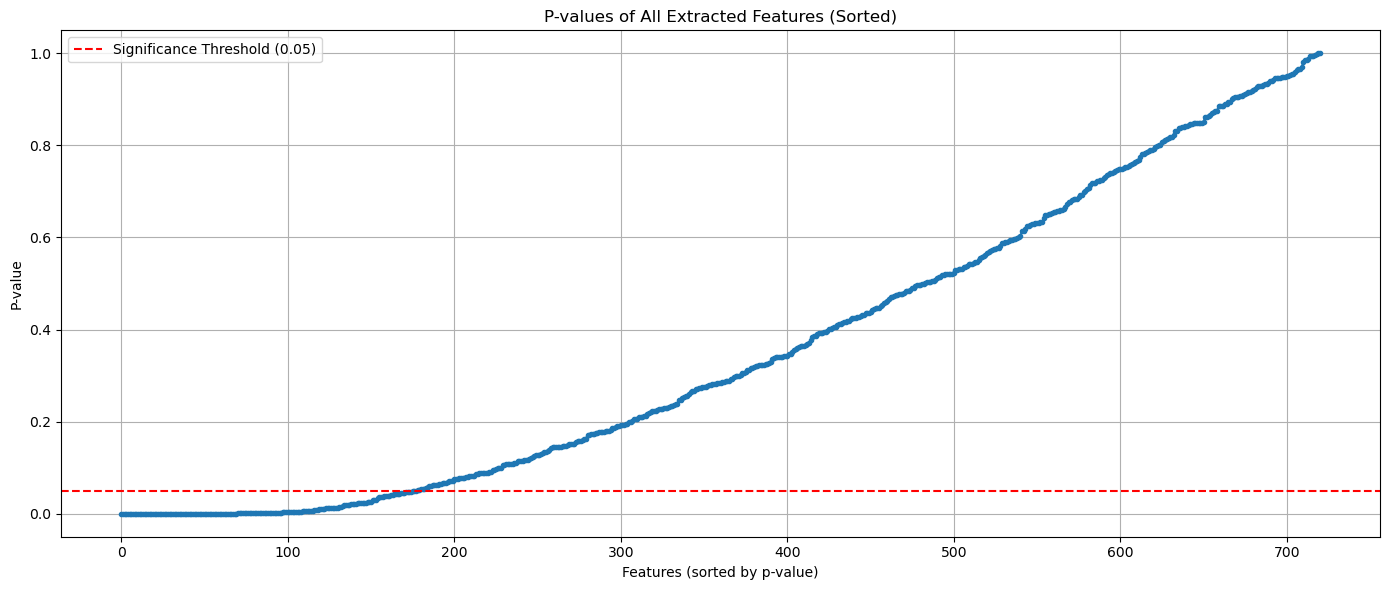

In [4]:
# Plot all p-values
sorted_relevance = relevance_table.sort_values(by="p_value")
plt.figure(figsize=(14, 6))
plt.plot(sorted_relevance["p_value"].values, marker='o', linestyle='-', markersize=3)
plt.axhline(y=0.05, color='red', linestyle='--', label='Significance Threshold (0.05)')
plt.title("P-values of All Extracted Features (Sorted)")
plt.xlabel("Features (sorted by p-value)")
plt.ylabel("P-value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

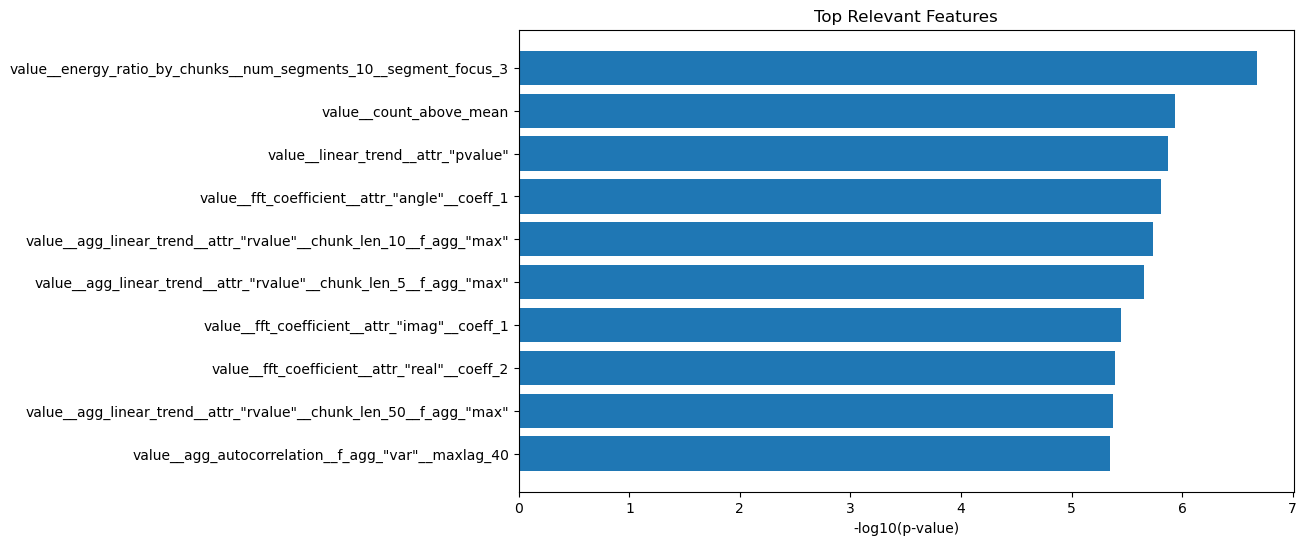

In [12]:
import numpy as np

plt.figure(figsize=(10, 6))
plt.barh(significant_features['feature'].head(10), -np.log10(significant_features['p_value'].head(10)))
plt.xlabel('-log10(p-value)')
plt.title('Top Relevant Features')
plt.gca().invert_yaxis()
plt.show()

c:\Users\Teresa\anaconda3\envs\audio_env\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Teresa\anaconda3\envs\audio_env\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Teresa\anaconda3\envs\audio_env\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Teresa\anaconda3\envs\audio_env\lib\site-packages\sklearn\cluster\_kmeans.py:14

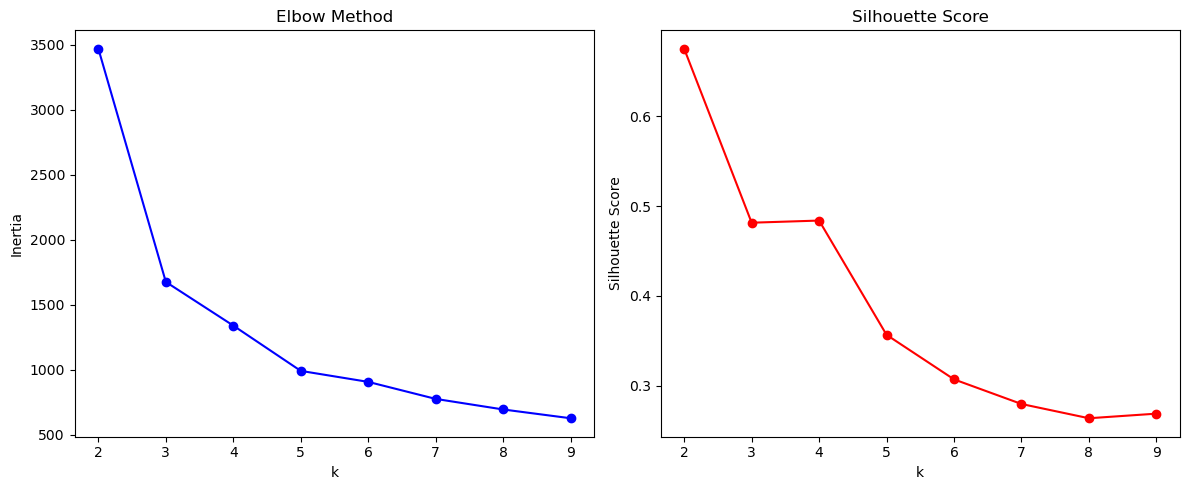

c:\Users\Teresa\anaconda3\envs\audio_env\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


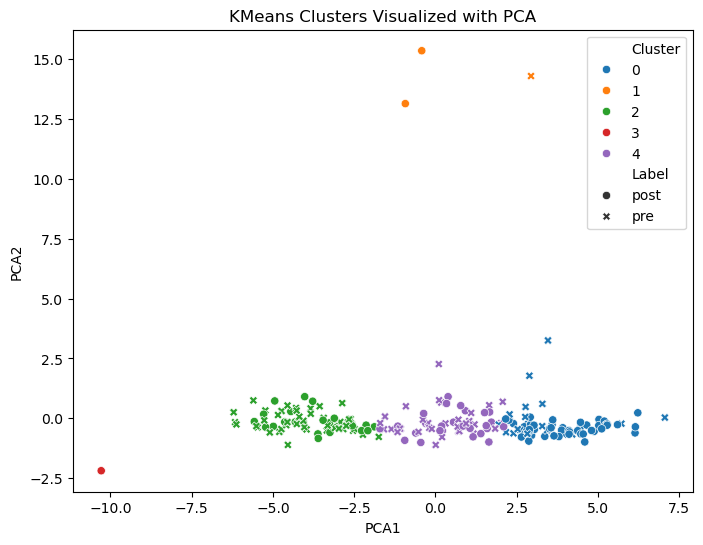


Cluster Composition:
Label    post  pre
Cluster           
0          49   19
1           2    1
2          23   47
3           1    0
4          30   33


In [6]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# === 1. Select top N relevant features ===
top_n = 20
top_features = significant_features.head(top_n)['feature'].tolist()
X_selected = X[top_features]

# === 2. Scale the features ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

# === 3. Find optimal k using elbow & silhouette methods ===
inertias = []
silhouettes = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot elbow and silhouette
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.subplot(1, 2, 2)
plt.plot(K_range, silhouettes, 'ro-')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')

plt.tight_layout()
plt.show()

# === 4. Apply KMeans with chosen k ===
optimal_k = 5  # Change based on plots
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

# === 5. PCA for visualization ===
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

viz_df = pd.DataFrame({
    'PCA1': X_pca[:, 0],
    'PCA2': X_pca[:, 1],
    'Cluster': cluster_labels,
    'Label': y.map({0: 'pre', 1: 'post'}).values
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=viz_df, x='PCA1', y='PCA2', hue='Cluster', style='Label', palette='tab10')
plt.title('KMeans Clusters Visualized with PCA')
plt.show()

# === 6. Analyze cluster composition ===
cluster_df = pd.DataFrame({'Cluster': cluster_labels, 'Label': y.map({0: 'pre', 1: 'post'})})
composition = pd.crosstab(cluster_df['Cluster'], cluster_df['Label'])
print("\nCluster Composition:")
print(composition)


Top 10 features | DBSCAN eps=0.5, min_samples=5 -> ARI: 0.520
Top 10 features | DBSCAN eps=1.0, min_samples=5 -> ARI: 0.754
Top 10 features | DBSCAN eps=1.5, min_samples=3 -> ARI: 0.936
Top 20 features | DBSCAN eps=0.5, min_samples=5 -> ARI: -0.067
Top 20 features | DBSCAN eps=1.0, min_samples=5 -> ARI: 0.639
Top 20 features | DBSCAN eps=1.5, min_samples=3 -> ARI: 0.892
Top 50 features | DBSCAN eps=0.5, min_samples=5 -> ARI: 0.000
Top 50 features | DBSCAN eps=1.0, min_samples=5 -> ARI: 0.000
Top 50 features | DBSCAN eps=1.5, min_samples=3 -> ARI: 0.084


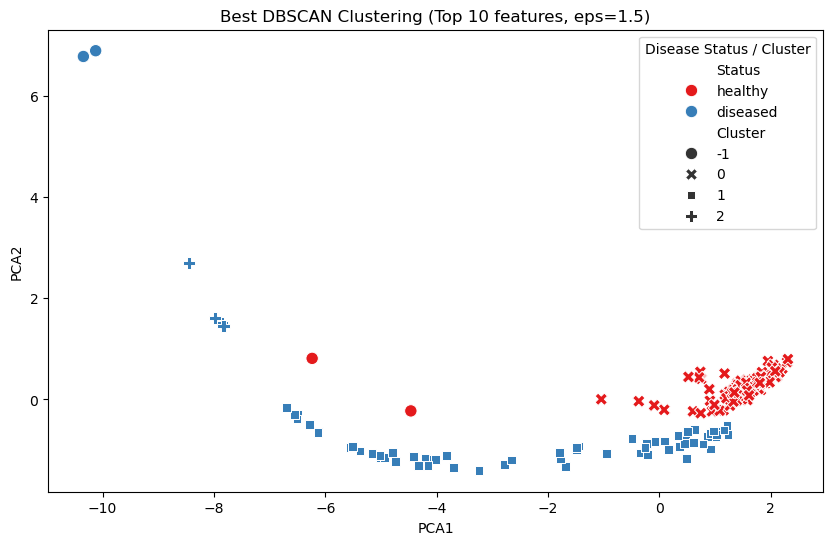


✅ Best Adjusted Rand Index (ARI): 0.936


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.metrics import adjusted_rand_score
from tsfresh.feature_selection.relevance import calculate_relevance_table

# --- Load data ---
df = pd.read_excel(r"C:\Users\Teresa\Desktop\MBBAS (2ºano)\Tese\Audio_samples\features.xlsx", engine="openpyxl")

# Extract labels
df['status'] = df.iloc[:, 0].apply(lambda x: 'healthy' if 'GC' in x else 'diseased')
df['status_binary'] = df['status'].map({'healthy': 0, 'diseased': 1})
df['label'] = df.iloc[:, 0].apply(lambda x: 'pre' if '_pre' in x else 'post')

# --- Prepare numeric feature matrix ---
X = df.drop(columns=[df.columns[0], 'label'])

# Keep only numeric columns
X = X.select_dtypes(include='number')

# Remove constant columns and those with too many NaNs
X = X.loc[:, X.nunique() > 1]
X = X.loc[:, X.isna().mean() <= 0.5]
X = X.fillna(0)  # Fill remaining NaNs

# Feature selection based on disease status
relevance_table = calculate_relevance_table(X, df['status_binary'])
significant_features = relevance_table[
    (relevance_table["relevant"] == True) & (relevance_table["p_value"] < 0.05)
].sort_values(by="p_value")

# Parameters to test
top_n_values = [10, 20, 50]
dbscan_params = [(0.5, 5), (1.0, 5), (1.5, 3)]
best_ari = -1
best_result = None

for top_n in top_n_values:
    top_features = significant_features.head(top_n)['feature'].tolist()
    X_selected = X[top_features]
    
    # Scale
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_selected)
    
    for eps, min_samples in dbscan_params:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        clusters = dbscan.fit_predict(X_scaled)

        ari = adjusted_rand_score(df['status_binary'], clusters)
        print(f"Top {top_n} features | DBSCAN eps={eps}, min_samples={min_samples} -> ARI: {ari:.3f}")
        
        if ari > best_ari:
            best_ari = ari
            best_result = {
                "top_n": top_n,
                "eps": eps,
                "min_samples": min_samples,
                "clusters": clusters,
                "X_scaled": X_scaled
            }

# --- Visualize best clustering ---
df['Best_Cluster'] = best_result['clusters']
pca = PCA(n_components=2)
pca_result = pca.fit_transform(best_result['X_scaled'])

viz_df = pd.DataFrame({
    'PCA1': pca_result[:, 0],
    'PCA2': pca_result[:, 1],
    'Cluster': best_result['clusters'],
    'Status': df['status']
})

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=viz_df,
    x='PCA1', y='PCA2',
    hue='Status',
    style='Cluster',
    palette='Set1',
    s=80
)
plt.title(f"Best DBSCAN Clustering (Top {best_result['top_n']} features, eps={best_result['eps']})")
plt.legend(title='Disease Status / Cluster')
plt.show()

print(f"\n✅ Best Adjusted Rand Index (ARI): {best_ari:.3f}")
